# Plotting Notebook (auto from artifacts)

This notebook loads the **latest** run exported by your analysis notebook and produces figures.
It is **name-agnostic**: it uses the `meta` attached to the artifacts (when available) to
find all summary tables and the "everything" table. It falls back to simple heuristics if
those keys are missing.


## Workflow

1. In the analysis notebook, run the export cell (right before any plotting) to write Parquet tables
   and a `meta.json` into a timestamped folder under `artifacts/`.
2. Open this notebook and run the cells top-to-bottom to generate figures from the latest run.
3. Figures are saved under `plots/<run_id>/` so every run remains reproducible.


In [1]:
# Load artifacts and resolve summary + everything tables
import os
import pandas as pd
from artifacts_io import load_artifacts

tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print("Loaded run:", run_dir)
print("Meta:", meta)

# Resolve keys from meta if present; otherwise infer
summary_keys = meta.get("summary_keys", [])
everything_key = meta.get("everything_key")

if not summary_keys:
    # Heuristic: names containing common summary tokens
    name_hits = ("summary", "sum_", "_sum", "agg", "group", "pivot", "tbl", "by_", "_by")
    summary_keys = [k for k in tables if any(tok in k.lower() for tok in name_hits)]

if everything_key is None:
    # Largest table by rows as the 'everything' table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])

print("\nResolved table keys:")
print("  summary_keys :", summary_keys if summary_keys else "(none)")
print("  everything_key:", everything_key)

# Preview heads
for k in tables:
    print(f"\nTable: {k}  shape={tables[k].shape}")
    display(tables[k].head(5))


Loaded run: artifacts\run_20250820_141313
Meta: {'created': '2025-08-20 14:13:13', 'n_tables': 5, 'notes': 'Summaries + full analysis table exported for plotting/other notebooks', 'source_notebook': 'working_datacrunch.ipynb', 'summary_keys': ['df_summary', 'summary_by_type', 'summary_by_year', 'summary_by_decade'], 'everything_key': 'df'}

Resolved table keys:
  summary_keys : ['df_summary', 'summary_by_type', 'summary_by_year', 'summary_by_decade']
  everything_key: df

Table: df  shape=(63713, 27)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,latitude,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,39.134720,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,35.933333,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,32.816667,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,38.500000,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True



Table: df_summary  shape=(63081, 28)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review,decade
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False,1960
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False,1910
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False,1920
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False,1910
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True,<NA>



Table: summary_by_decade  shape=(102, 5)


,water_type_clean,decade,n_rows,n_pages,n_docs
0,Groundwater,1850,1,1,1
1,Groundwater,1860,5,3,2
2,Groundwater,1870,53,44,10
3,Groundwater,1880,174,93,12
4,Groundwater,1890,244,90,17



Table: summary_by_type  shape=(9, 4)


,water_type_clean,n_rows,n_pages,n_docs
0,Groundwater,11575,3118,325
1,Irrigation,1408,832,214
2,Not water related,392,210,135
3,Other,6,3,2
4,Precipitation,483,191,95



Table: summary_by_year  shape=(685, 5)


,water_type_clean,year_start,n_rows,n_pages,n_docs
0,Groundwater,1856,1,1,1
1,Groundwater,1863,1,1,1
2,Groundwater,1868,3,2,1
3,Groundwater,1869,1,1,1
4,Groundwater,1870,4,4,3


## Optional: Export convenient CSV copies

If you want quick CSVs alongside the Parquet artifacts, run this cell. (Parquet remains the
authoritative format; CSV is for ad‑hoc inspection.) Files are written under `exports/<run_id>/`.


In [ ]:
import os
export_dir = os.path.join("exports", run_id)
os.makedirs(export_dir, exist_ok=True)

# Write summary tables
for key in summary_keys:
    if key in tables:
        path = os.path.join(export_dir, f"{key}.csv")
        tables[key].to_csv(path, index=False)
        print("Wrote", path)

# Write the everything table
if everything_key in tables:
    path = os.path.join(export_dir, f"{everything_key}.csv")
    tables[everything_key].to_csv(path, index=False)
    print("Wrote", path)


# Plot 1 — Water Category summary (grouped bar)

**Source table:** `summary_by_type`

**Spec:** Grouped horizontal bar plot with one row per water category and three bars per row representing `n_rows`, `n_pages`, and `n_docs`. Filters to the specified categories only. Exports 300 DPI PNG to `plots/<run_id>/watercat_summary.png`.


Saved figure to: plots\run_20250820_141313\watercat_summary.png


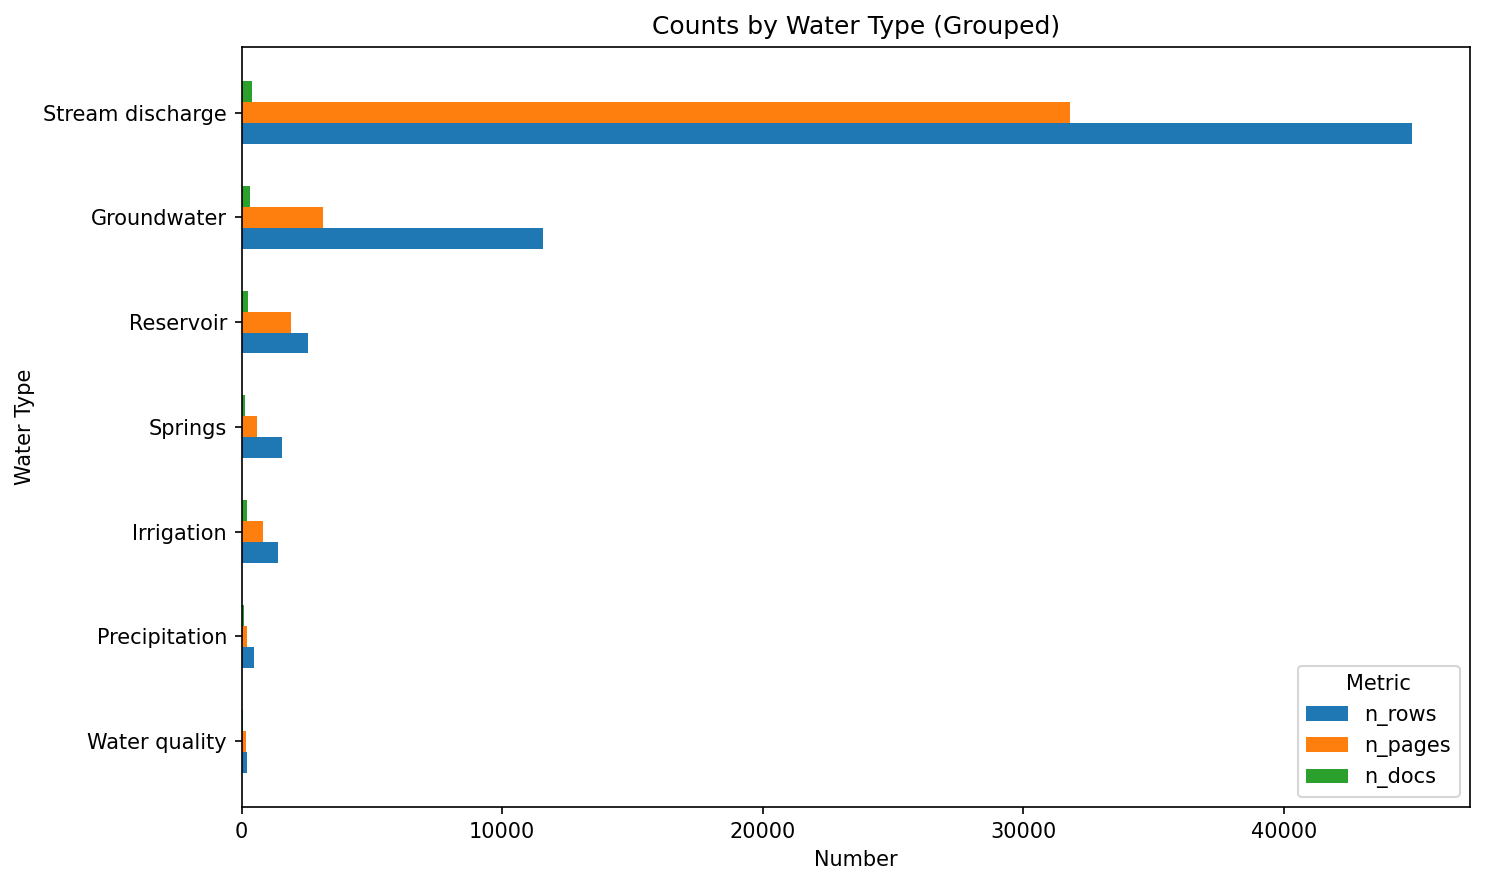

In [2]:

# --- Plot 1: grouped bar for summary_by_type ---
import os
import pandas as pd
import matplotlib.pyplot as plt
from artifacts_io import load_artifacts

# Load latest artifacts
tables, meta, run_dir = load_artifacts(out_dir="artifacts")

# Retrieve the source table
if "summary_by_type" not in tables:
    raise KeyError("The table 'summary_by_type' was not found in the saved artifacts. "
                   "Please ensure your analysis notebook saves it.")

df = tables["summary_by_type"].copy()

# Identify the category column (flexible naming)
cat_col_candidates = [c for c in df.columns if "water" in c.lower() and ("type" in c.lower() or "category" in c.lower())]
if not cat_col_candidates:
    # fallback: try a few common names
    for c in ["Water Category","Water Type","water_category","water_type","category","type"]:
        if c in df.columns:
            cat_col_candidates = [c]
            break

if not cat_col_candidates:
    raise KeyError("Could not identify the water category column in 'summary_by_type'. "
                   "Expected something like 'Water Category' or 'Water Type'.")

cat_col = cat_col_candidates[0]

# Ensure required metrics exist
metrics = ["n_rows","n_pages","n_docs"]
missing = [m for m in metrics if m not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns in 'summary_by_type': {missing}. "
                   "Please ensure your analysis exported these metrics.")

# Filter to the requested categories (case-insensitive, robust to spacing)
wanted = ["groundwater","irrigation","stream discharge","precipitation","reservoir","springs","water quality"]

def norm(s):
    return str(s).strip().lower()

df["_norm_cat"] = df[cat_col].map(norm)
mask = df["_norm_cat"].isin([norm(x) for x in wanted])
df_f = df.loc[mask].copy()

# If some requested categories are absent, we can optionally warn
missing_cats = [w for w in wanted if norm(w) not in set(df_f["_norm_cat"])]
if missing_cats:
    print("Warning: These requested categories were not found in the table:", missing_cats)

# Sort categories by the largest metric to produce a nice order
df_f["max_metric"] = df_f[metrics].max(axis=1)
df_f = df_f.sort_values("max_metric", ascending=True)

# Prepare grouped horizontal bar
cats = df_f[cat_col].tolist()
import numpy as np
y = np.arange(len(cats))
bar_height = 0.2  # spacing for grouped bars

plt.figure(figsize=(10, 6), dpi=150)

for i, m in enumerate(metrics):
    plt.barh(y + (i - 1) * bar_height, df_f[m].values, height=bar_height, label=m)

plt.xlabel("Number")
plt.ylabel("Water Type")
plt.title("Counts by Water Type (Grouped)")
plt.yticks(y, cats)
plt.legend(title="Metric")
plt.tight_layout()

# Save export
run_id = os.path.basename(run_dir)
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "watercat_summary.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved figure to:", outfile)

plt.show()

# Optional: also export the filtered table for reference
exp_dir = os.path.join("exports", run_id)
os.makedirs(exp_dir, exist_ok=True)
df_f.drop(columns=["_norm_cat","max_metric"], errors="ignore").to_csv(os.path.join(exp_dir, "summary_by_type_filtered.csv"), index=False)
